In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
data = "../data/heart_disease_cleaned.csv"
df = pd.read_csv(data)

In [7]:
print(df.shape)
print(df.head())

(302, 14)
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.949794  0.682656  1.976470  0.764066 -0.261285  2.389793 -1.002541   
1 -1.928548  0.682656  1.005911 -0.091401  0.067741 -0.418446  0.901657   
2 -1.485726 -1.464866  0.035352 -0.091401 -0.822564 -0.418446 -1.002541   
3  0.174856  0.682656  0.035352 -0.661712 -0.203222 -0.418446  0.901657   
4  0.285561 -1.464866 -0.935208 -0.661712  2.080602 -0.418446  0.901657   

    thalach     exang   oldpeak     slope        ca      thal    target  
0  0.018826 -0.698344  1.084022 -2.271182 -0.714911 -2.147955  0.917313  
1  1.636979 -0.698344  2.118926 -2.271182 -0.714911 -0.513994  0.917313  
2  0.980971 -0.698344  0.307844  0.979514 -0.714911 -0.513994  0.917313  
3  1.243374 -0.698344 -0.209608  0.979514 -0.714911 -0.513994  0.917313  
4  0.587366  1.431958 -0.382092  0.979514 -0.714911 -0.513994  0.917313  


In [8]:
if 'target' in df.columns:
    X = df.drop(columns=['target'])
    y = df['target']
else:
    X = df.copy()
    y = None

In [9]:
pca = PCA()
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

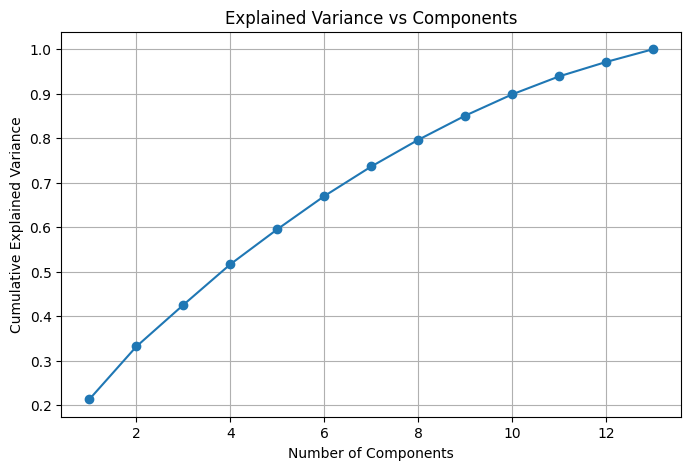

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Components")
plt.grid()
plt.show()

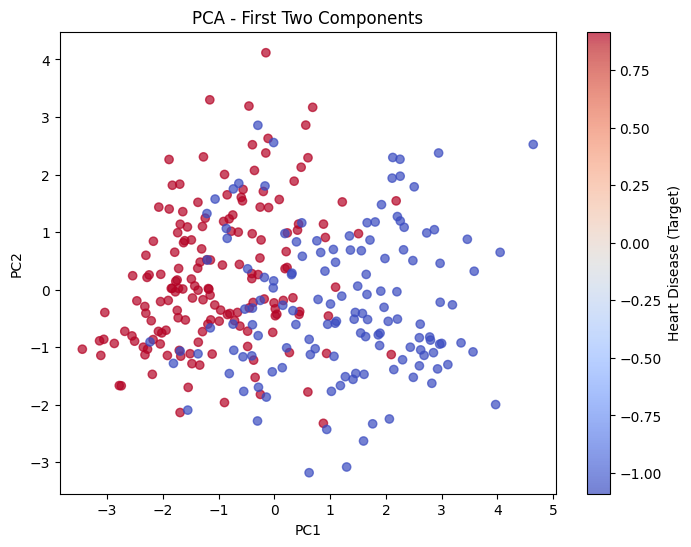

In [11]:
plt.figure(figsize=(8, 6))
if y is not None:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
    plt.colorbar(label="Heart Disease (Target)")
else:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - First Two Components")
plt.show()

In [12]:
n_components = (cumulative_variance < 0.95).sum() + 1
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)])
if y is not None:
    df_pca['target'] = y.values

In [13]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,0.682656,1.976470,0.764066,-0.261285,2.389793,-1.002541,0.018826,-0.698344,1.084022,-2.271182,-0.714911,-2.147955,0.917313
1,-1.928548,0.682656,1.005911,-0.091401,0.067741,-0.418446,0.901657,1.636979,-0.698344,2.118926,-2.271182,-0.714911,-0.513994,0.917313
2,-1.485726,-1.464866,0.035352,-0.091401,-0.822564,-0.418446,-1.002541,0.980971,-0.698344,0.307844,0.979514,-0.714911,-0.513994,0.917313
3,0.174856,0.682656,0.035352,-0.661712,-0.203222,-0.418446,0.901657,1.243374,-0.698344,-0.209608,0.979514,-0.714911,-0.513994,0.917313
4,0.285561,-1.464866,-0.935208,-0.661712,2.080602,-0.418446,0.901657,0.587366,1.431958,-0.382092,0.979514,-0.714911,-0.513994,0.917313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,0.285561,-1.464866,-0.935208,0.478910,-0.106449,-0.418446,0.901657,-1.161988,1.431958,-0.727060,-0.645834,-0.714911,1.119967,-1.090140
298,-1.042904,0.682656,1.976470,-1.232023,0.338703,-0.418446,0.901657,-0.768384,-0.698344,0.135360,-0.645834,-0.714911,1.119967,-1.090140
299,1.503322,0.682656,-0.935208,0.707035,-1.035462,2.389793,0.901657,-0.374779,-0.698344,2.032684,-0.645834,1.274980,1.119967,-1.090140
300,0.285561,0.682656,-0.935208,-0.091401,-2.235438,-0.418446,0.901657,-1.511859,1.431958,0.135360,-0.645834,0.280034,1.119967,-1.090140


In [14]:
df_pca.to_csv("../data/heart_disease_pca.csv", index=False)